In [ ]:
# Example to run the parachor.py module and running together with thermoift

import time
notebook_start = time.perf_counter()

# %pip install -e /home/darshan/A6/PCSAFT_cDFT/parachorpy
# %pip install -e /home/darshan/A6/PCSAFT_cDFT

from Interfacethermopy import parachor as IFT
import matplotlib.pyplot as plt, matplotlib.ticker as ticker
import thermoift.PLOT_SETTINGS as ps

In [2]:
if __name__ == '__main__':
    
    json_files = ["Mulero_2012.json"]
    model = IFT.InterfacialTension(json_files)
    
    model.ctREFPROP_init('~/Software/REFPROP/REFPROP-cmake/build', gerg_enable=1)
    
    MIXTURE  = "CO2;Hydrogen;Argon"
    z        = [0.9500, 0.0167, 0.0333]
    kij      = 0.0
    phi_ij   = 1.0

    ### Option 1: only saturation boundaries #######################
    mode = "saturation"

    df_sat, df_bub_sat, df_dew_sat = model.compute_IFT_envelope(
        mixture  = MIXTURE,
        z        = z,
        T_start  = 200,
        kij      = kij,
        phi_ij   = phi_ij,
        tol_frac = 5e-6,
        mode     = mode)

    df_sat.to_csv("IFT_semi_empirical_saturation.csv", index=False)

    ### Option 2: full sweep inside two-phase region ################
    mode = "envelope"

    df_env, df_bub_env, df_dew_env = model.compute_IFT_envelope(
        mixture  = MIXTURE,
        z        = z,
        T_start  = 200,
        N_points = 20,
        kij      = kij,
        phi_ij   = phi_ij,
        tol_frac = 5e-6,
        mode     = mode)

    df_env.to_csv("IFT_semi_empirical_envelope.csv", index=False)

REFPROP version = 10.0
GERG-2008 model = Enabled
Mixture critical point:  Tc = 300.0662 K  |  Pc = 80.9675 bar
Mode: 'saturation' | 2 points per T (bubble + dew)
Given temperature is less than or equal to max(TMIN, TTRP) for CO2
Computing interfacial tension at T = 1.1*max(TMIN, TTRP) for Parachor method for mixtures
Parachor number calculated: 77.784598 [kg/m3]n ·mN/m
Given temperature is greater than Tc (33.19) for Hydrogen
Computing interfacial tension at T = 0.9*33.19 for Parachor method
Parachor number calculated: 34.881439 [kg/m3]n ·mN/m
Given temperature is greater than Tc (150.687) for Argon
Computing interfacial tension at T = 0.9*150.687 for Parachor method
Parachor number calculated: 55.915310 [kg/m3]n ·mN/m
Given temperature is less than or equal to max(TMIN, TTRP) for CO2
Computing interfacial tension at T = 1.1*max(TMIN, TTRP) for Parachor method for mixtures
Parachor number calculated: 77.784598 [kg/m3]n ·mN/m
Given temperature is greater than Tc (33.19) for Hydrogen
Com

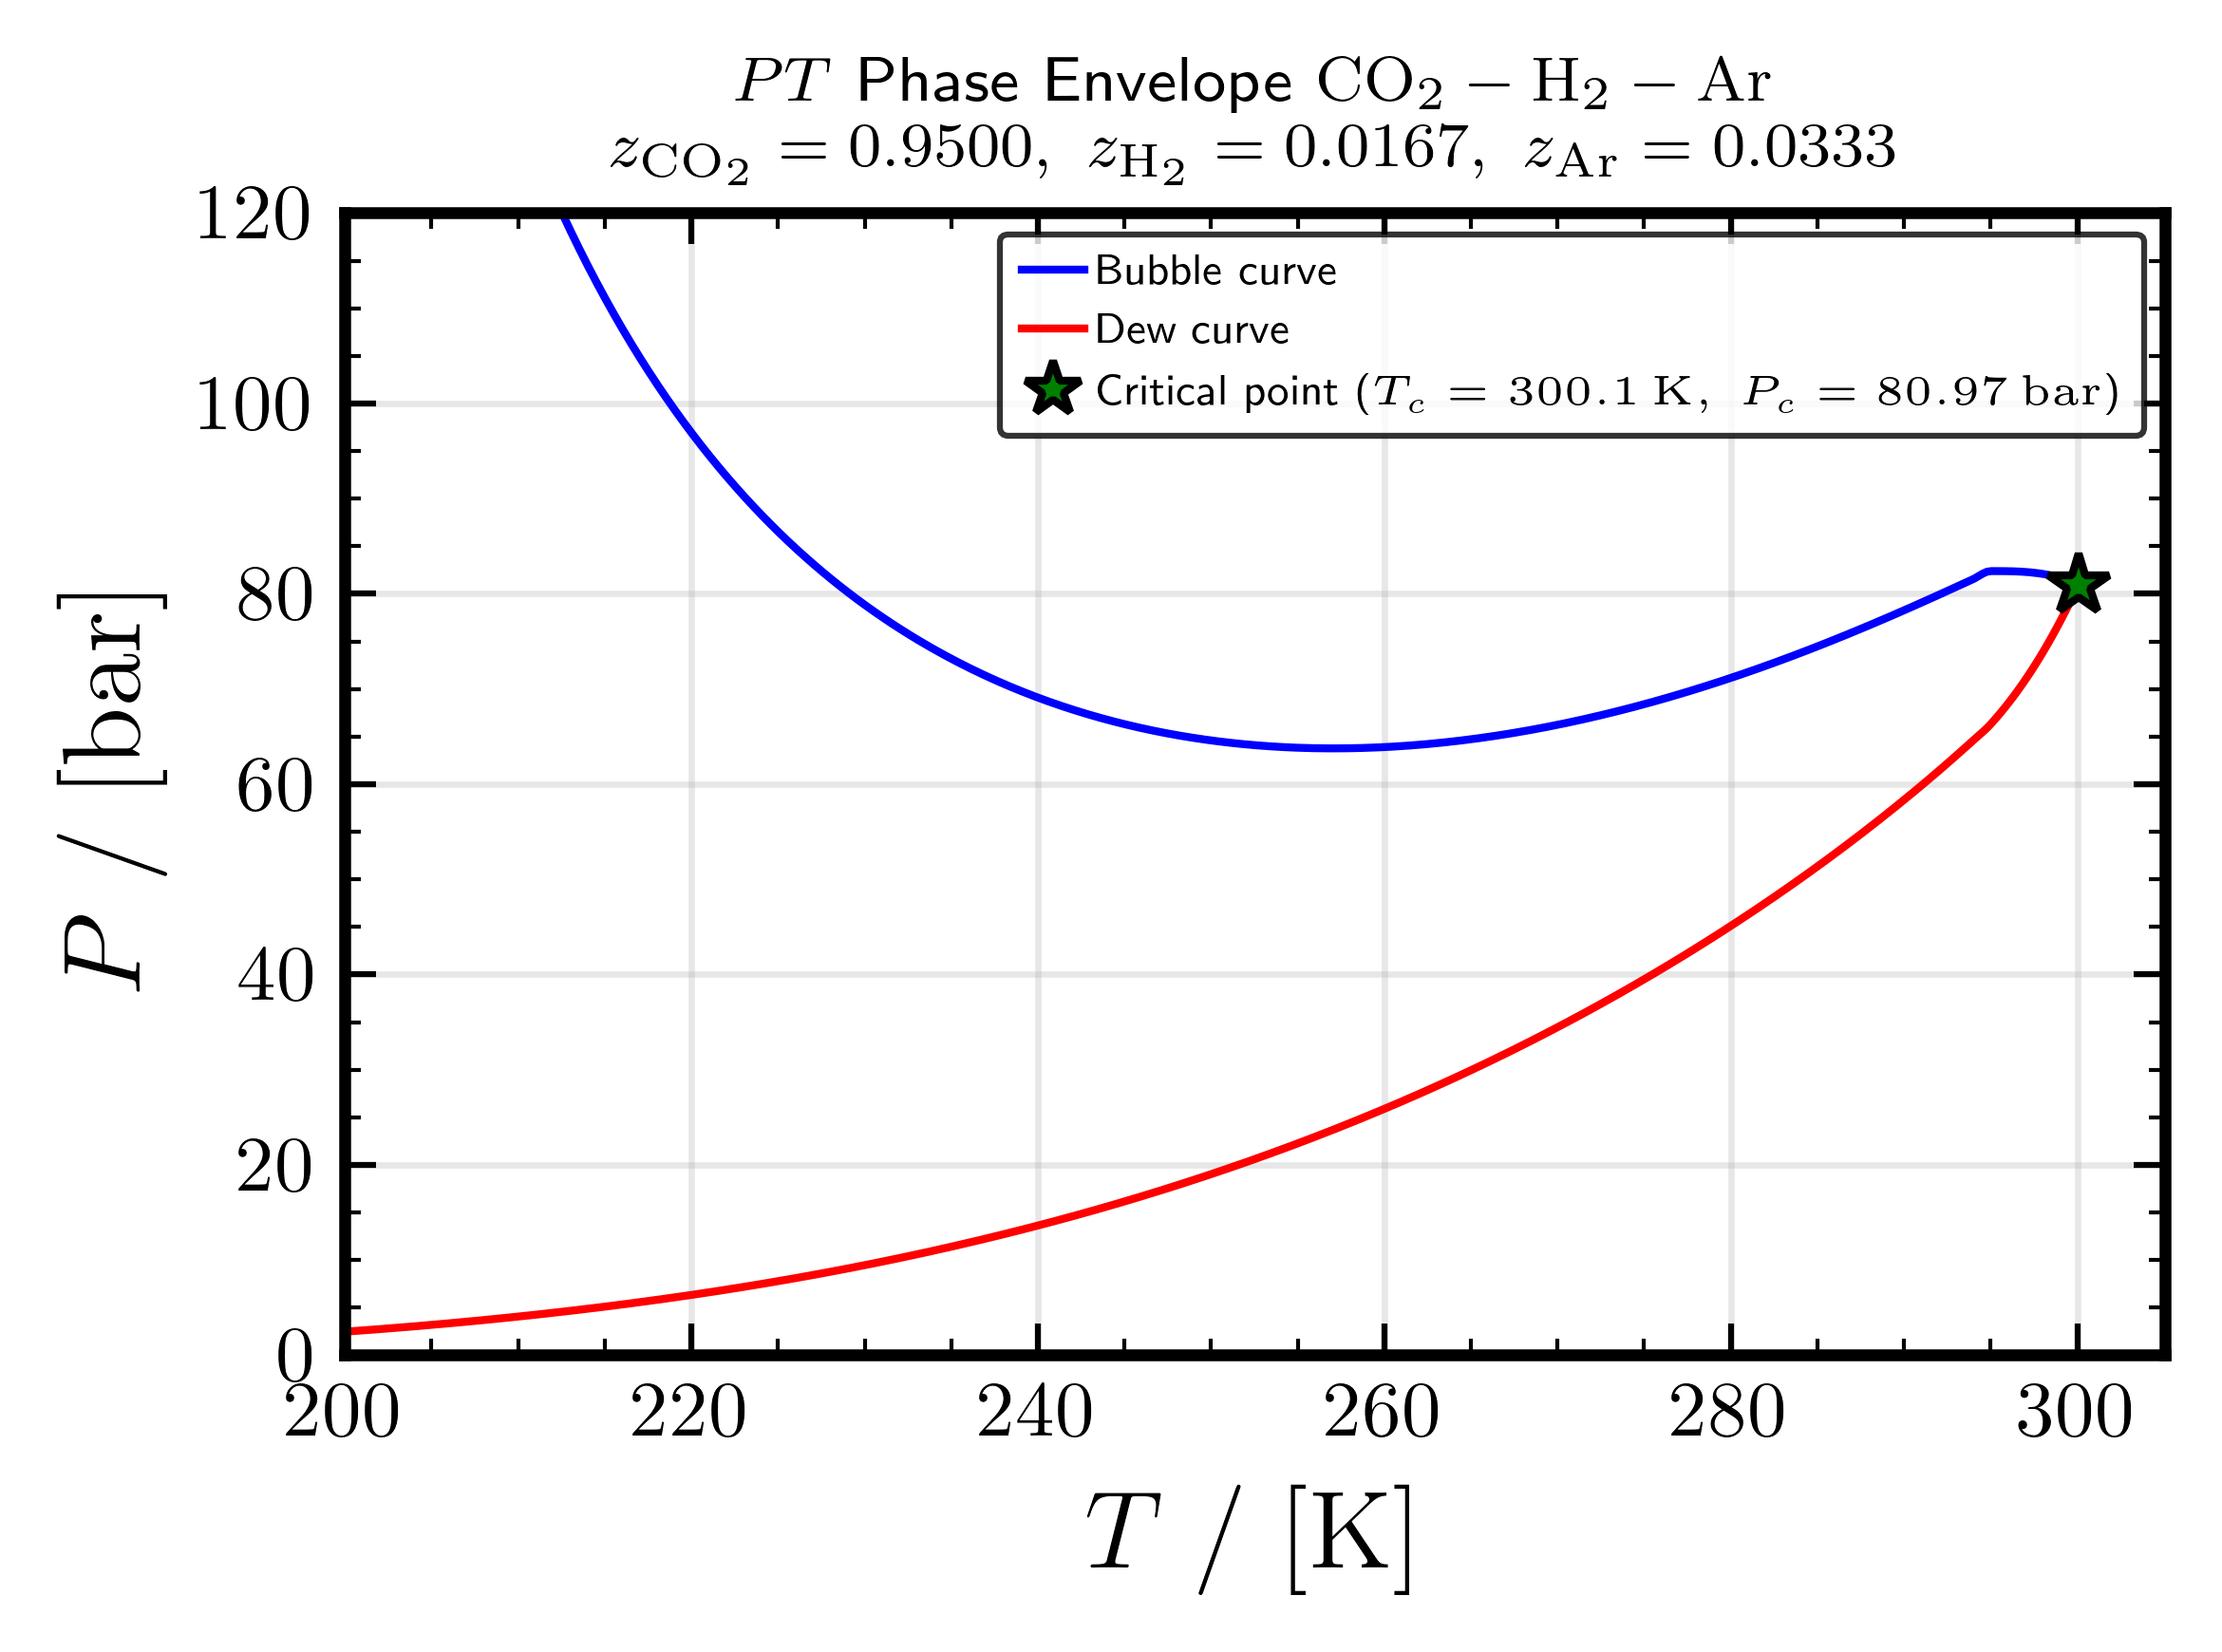

In [4]:
env = model.PT_envelope_curves("IFT_semi_empirical_saturation.csv", n_smooth=400)

fig, ax = ps.plot_init()

ax.plot(env["T_bub_smooth"],env["P_bub_smooth"],linestyle='-',
    color='b',linewidth=ps.linewidth,label="Bubble curve")

ax.plot(env["T_dew_smooth"],env["P_dew_smooth"], linestyle='-',
    color='r',linewidth=ps.linewidth,label="Dew curve")

ax.plot(env["Tc"],env["Pc"],marker="*",linestyle="None",color="k",ms=8, markerfacecolor=ps.colors[1],
    label=fr"Critical point ($T_c={env['Tc']:.1f}\,\mathrm{{K}},\ P_c={env['Pc']:.2f}\,\mathrm{{bar}}$)")

ax.set_xlabel(r'$T \; / \; [\mathrm{K}]$', fontsize=ps.label_fontsize)
ax.set_ylabel(r'$P \; / \; [\mathrm{bar}]$', fontsize=ps.label_fontsize)

mixture_latex = ps.format_mixture_latex(env["mixture"])
z_latex = ps.format_z_latex(env["mixture"], z)

ax.set_title(fr"$PT$ Phase Envelope {mixture_latex}" "\n" + z_latex, fontsize=ps.title_fontsize/1.5)
ax.minorticks_on()
ax.grid(True, alpha=0.3)
ps.style_legend(ax, fontsize=ps.legend_fontsize/1.5, loc="best")
plt.tight_layout()
plt.xlim(200, None)
plt.ylim(0, 120)
ps.save_plot(fig, "PT_phase_envelope")
plt.show()

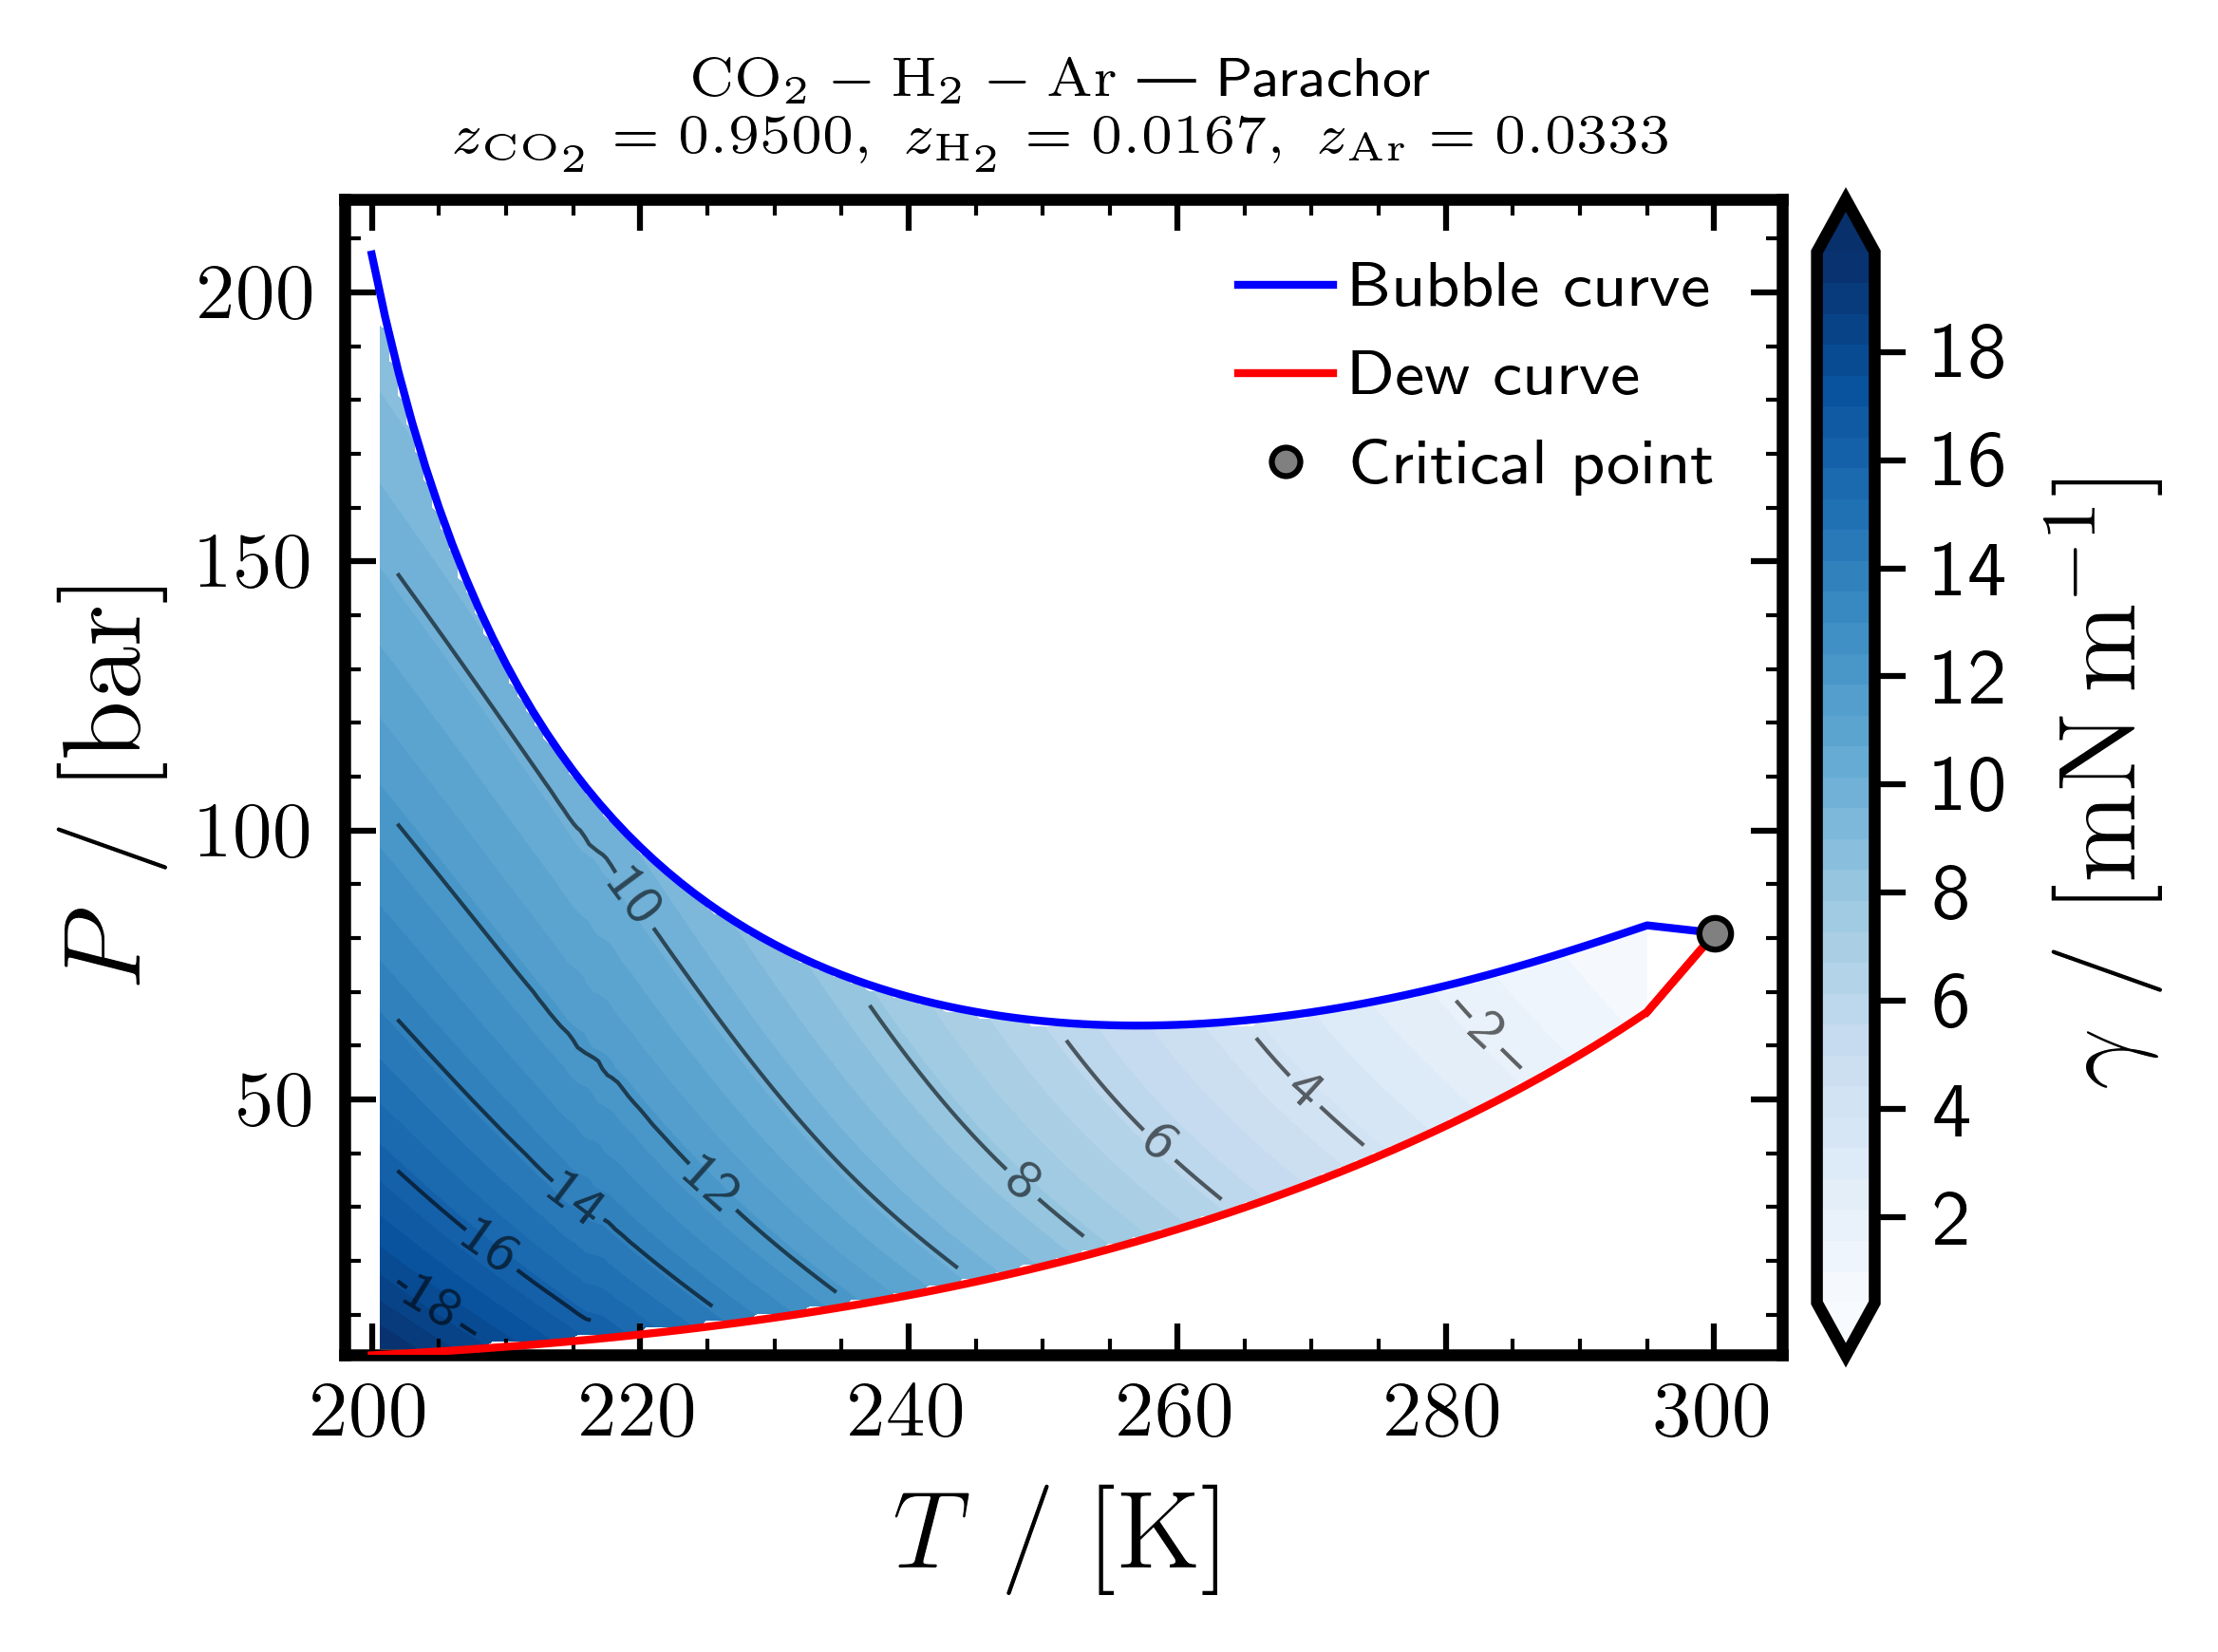

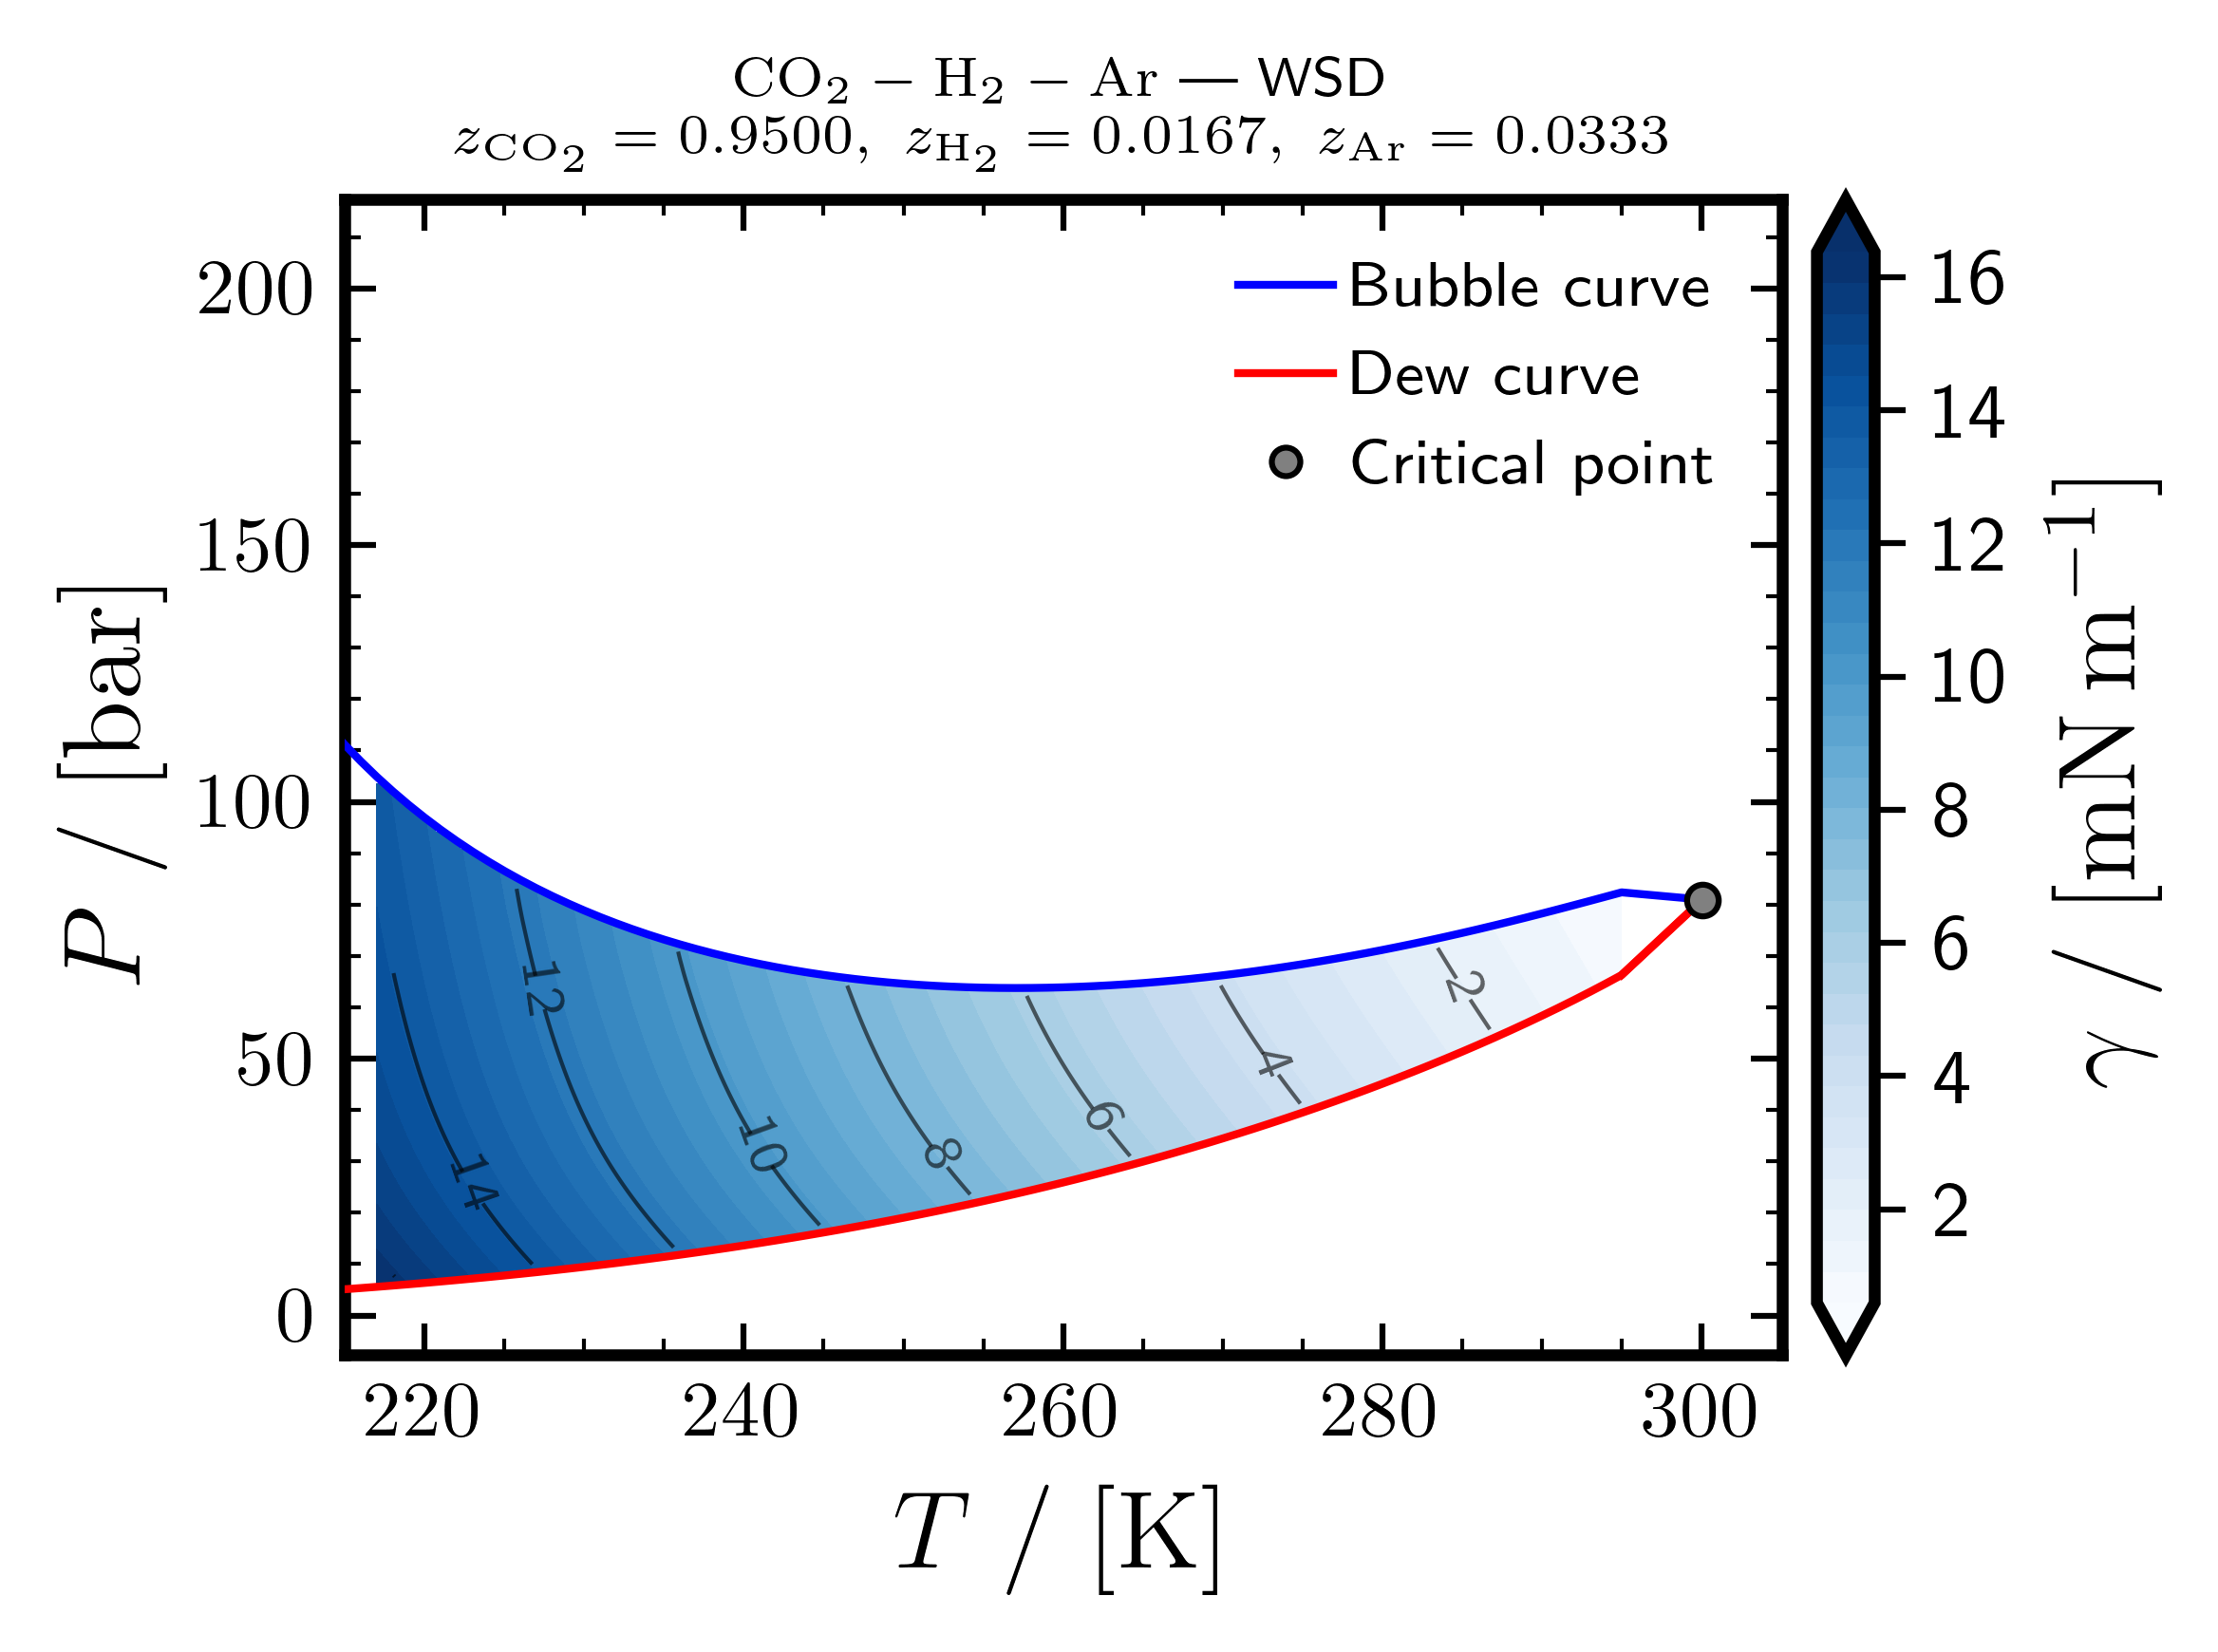

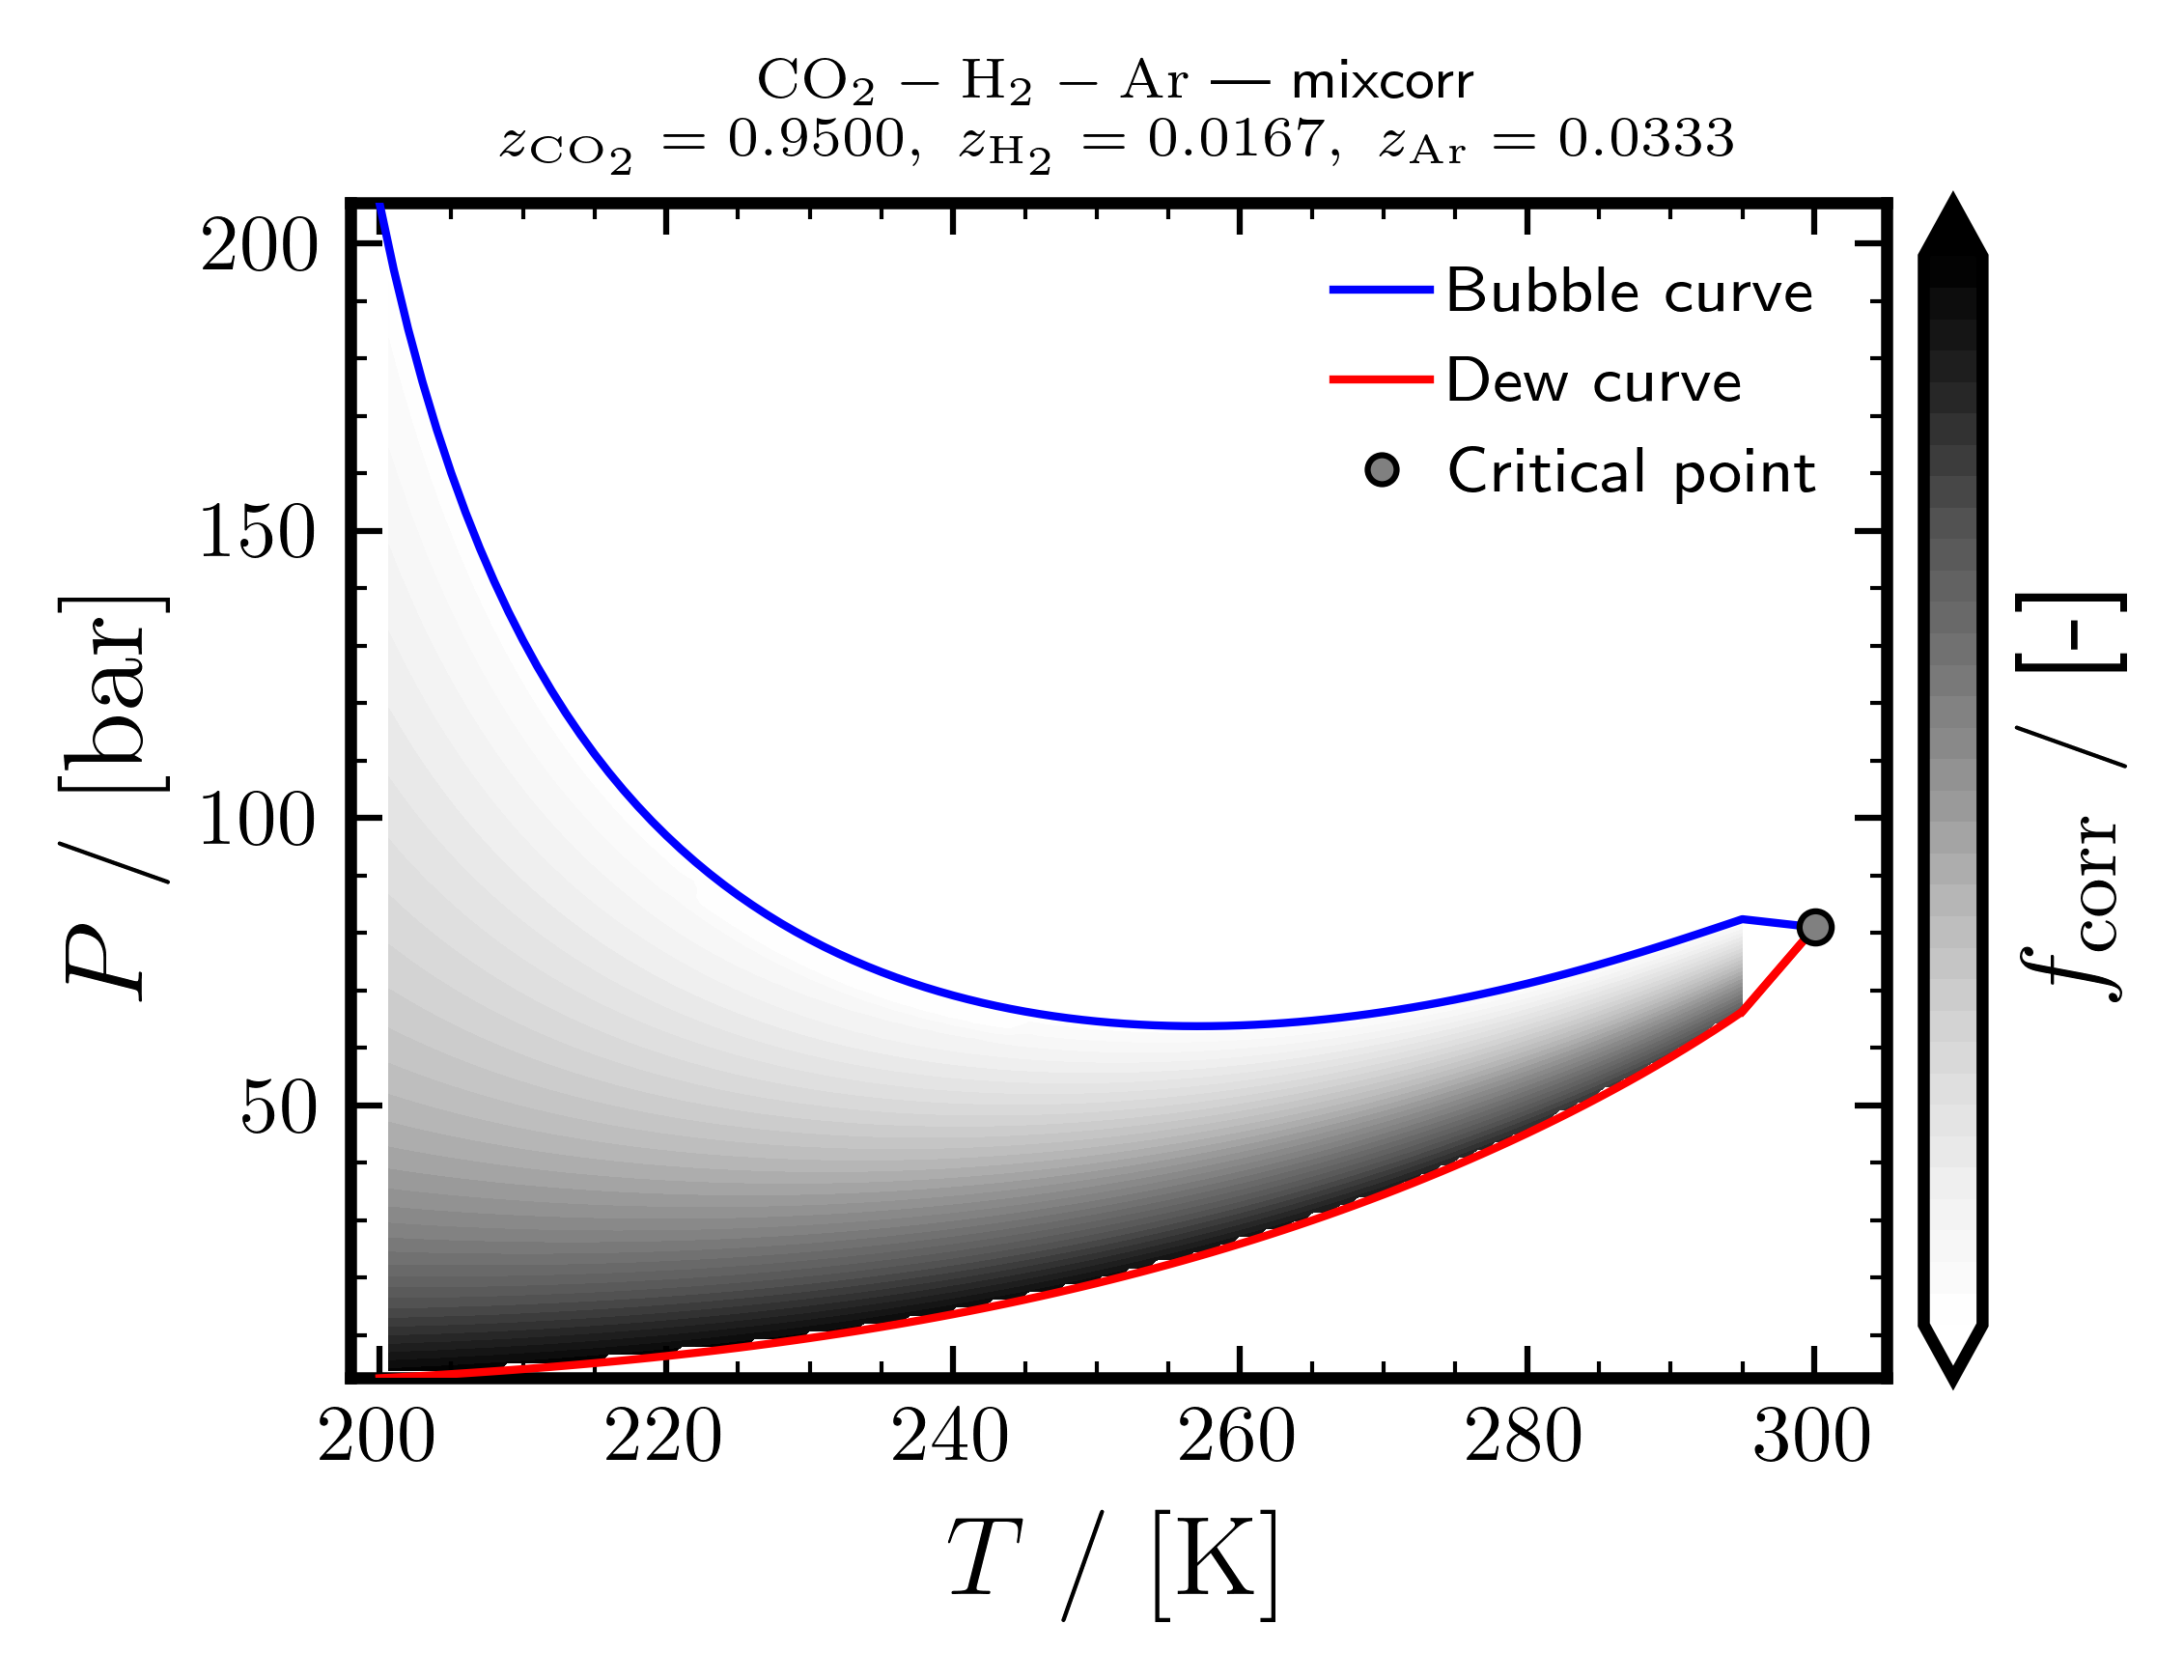

In [5]:
CSV_FILE_ENVELOPE = "IFT_semi_empirical_envelope.csv"

# --- Parachor ---
fig, ax = model.plot_IFT_colormap(
    csv_path  = CSV_FILE_ENVELOPE,
    model_key = "Parachor",
    save_path = "IFT_Parachor",        # saves IFT_Parachor.png + IFT_Parachor.pdf
)

# --- WSD ---
fig, ax = model.plot_IFT_colormap(
    csv_path  = CSV_FILE_ENVELOPE,
    model_key = "WSD",
    save_path = "IFT_WSD",
)

# --- WSD mixture correction ---
fig, ax = model.plot_IFT_colormap(
    csv_path  = CSV_FILE_ENVELOPE,
    model_key = "mixcorr",
    save_path = "IFT_mixcorr",
)

In [6]:
notebook_end    = time.perf_counter()
elapsed_minutes = (notebook_end - notebook_start) / 60
print(f"Total notebook runtime: {elapsed_minutes:.2f} minutes")

Total notebook runtime: 3.64 minutes
